In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part 1: Merge and Prepare the Required Datasets

### 1. Read all files that we need

In [5]:
results = pd.read_csv("1-Formula_One/results.csv")
pit_stops = pd.read_csv("1-Formula_One/pit_stops.csv")
qualifying = pd.read_csv("1-Formula_One/qualifying.csv")
races = pd.read_csv("1-Formula_One/races.csv")
drivers = pd.read_csv("1-Formula_One/drivers.csv")
constructors = pd.read_csv("1-Formula_One/constructors.csv")

### 2. Create a summary table to store the number of rows and columns for each dataset

In [6]:
print("results:", results.shape)
print("pit_stops:", pit_stops.shape)
print("qualifying:", qualifying.shape)
print("races:", races.shape)
print("drivers:", drivers.shape)
print("constructors:", constructors.shape)

results: (25660, 18)
pit_stops: (9299, 7)
qualifying: (9395, 9)
races: (1079, 18)
drivers: (854, 9)
constructors: (211, 5)


### 3. Clean and summarize pit stop data

In [7]:
# Convert pit stop time from milliseconds to seconds
pit_stops["pit_seconds"] = pit_stops["milliseconds"] / 1000

# Group by raceId and driverId so that each row represents one driver in one race
pit_summary = pit_stops.groupby(["raceId", "driverId"]).agg(
    avg_pit_seconds=("pit_seconds", "mean"),
    total_pit_seconds=("pit_seconds", "sum"),
    num_pit_stops=("pit_seconds", "count")
)

# Reset the index so raceId and driverId become regular columns again
pit_summary = pit_summary.reset_index()

pit_summary.head()

,raceId,driverId,avg_pit_seconds,total_pit_seconds,num_pit_stops
0,841,1,23.213,46.426,2
1,841,2,24.046,48.092,2
2,841,3,23.716,23.716,1
3,841,4,24.055,72.165,3
4,841,5,24.865,24.865,1


### 4. Clean qualifying data

In [8]:
# Keep only the columns we need from the qualifying dataset
qualifying_clean = qualifying[["raceId", "driverId", "position"]]

# Rename the position column so it clearly means qualifying position
qualifying_clean = qualifying_clean.rename(
    columns={"position": "qualifying_position"}
)

qualifying_clean.head()

,raceId,driverId,qualifying_position
0,18,1,1
1,18,9,2
2,18,5,3
3,18,13,4
4,18,2,5


### 5. Merge all datasets

In [9]:
f1_merged = results

# Merge pit stop summary into the main dataset
f1_merged = f1_merged.merge(
    pit_summary,
    on=["raceId", "driverId"],
    how="left"
)

# We merge by raceId and driverId because qualifying position is also for each driver in each race
f1_merged = f1_merged.merge(
    qualifying_clean,
    on=["raceId", "driverId"],
    how="left"
)


# raceId connects each result to race-level information such as year, round, and race name
f1_merged = f1_merged.merge(
    races,
    on="raceId",
    how="left"
)


# driverId connects each result to driver-level information such as driver name and nationality
f1_merged = f1_merged.merge(
    drivers,
    on="driverId",
    how="left"
)


# constructorId connects each result to team-level information
f1_merged = f1_merged.merge(
    constructors,
    on="constructorId",
    how="left"
)

f1_merged.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_y,constructorRef,name_y,nationality_y,url
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


### 6. Create core variables

In [10]:
f1_merged["driver_name"] = f1_merged["forename"] + " " + f1_merged["surname"]

# Calculate how many positions the driver gained during the race
f1_merged["positions_gained"] = f1_merged["grid"] - f1_merged["positionOrder"]

# Create a podium variable
# If positionOrder is 1, 2, or 3, then the driver got a podium finish
f1_merged["podium"] = f1_merged["positionOrder"] <= 3

# Create a finished_top_10 variable
# If positionOrder is 10 or lower, then the driver finished in the top 10
f1_merged["finished_top_10"] = f1_merged["positionOrder"] <= 10

f1_merged[[
    "driver_name",
    "grid",
    "positionOrder",
    "positions_gained",
    "podium",
    "finished_top_10"
]].head()

,driver_name,grid,positionOrder,positions_gained,podium,finished_top_10
0,Lewis Hamilton,1,1,0,True,True
1,Nick Heidfeld,5,2,3,True,True
2,Nico Rosberg,7,3,4,True,True
3,Fernando Alonso,11,4,7,False,True
4,Heikki Kovalainen,3,5,-2,False,True


### 7. Basic cleaning

In [11]:
# Keep only rows where the driver had a valid starting grid position
f1_clean = f1_merged[f1_merged["grid"] > 0]

# Keep only rows where positionOrder is not missing
f1_clean = f1_clean[f1_clean["positionOrder"].notna()]

f1_clean.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,nationality_x,url_y,constructorRef,name_y,nationality_y,url,driver_name,positions_gained,podium,finished_top_10
0,1,18,1,1,22,1,1,1,1,10.0,...,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Lewis Hamilton,0,True,True
1,2,18,2,2,3,5,2,2,2,8.0,...,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Nick Heidfeld,3,True,True
2,3,18,3,3,7,7,3,3,3,6.0,...,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Nico Rosberg,4,True,True
3,4,18,4,4,5,11,4,4,4,5.0,...,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Fernando Alonso,7,False,True
4,5,18,5,1,23,3,5,5,5,4.0,...,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Heikki Kovalainen,-2,False,True


### 8. Prepare the final analysis dataset

In [12]:
# Keep only rows with pit stop information
f1_analysis = f1_clean.dropna(subset=["avg_pit_seconds"]).copy()

# Rename confusing merged columns
f1_analysis = f1_analysis.rename(columns={
    "name_x": "race_name",
    "name_y": "constructor_name"
})

# Make sure important columns are numeric
numeric_columns = [
    "avg_pit_seconds",
    "positions_gained",
    "positionOrder",
    "points",
    "grid",
    "year"
]

for col in numeric_columns:
    f1_analysis[col] = pd.to_numeric(f1_analysis[col], errors="coerce")

# Create a clearer finish position column
f1_analysis["finish_position"] = f1_analysis["positionOrder"]

# Check the cleaned dataset
f1_analysis[[
    "year",
    "race_name",
    "driver_name",
    "constructor_name",
    "grid",
    "finish_position",
    "positions_gained",
    "avg_pit_seconds",
    "points"
]].head()

,year,race_name,driver_name,constructor_name,grid,finish_position,positions_gained,avg_pit_seconds,points
20776,2011,Australian Grand Prix,Sebastian Vettel,Red Bull,1,1,0,23.319500,25.0
20777,2011,Australian Grand Prix,Lewis Hamilton,McLaren,2,2,0,23.213000,18.0
20778,2011,Australian Grand Prix,Vitaly Petrov,Renault,6,3,3,25.109000,15.0
20779,2011,Australian Grand Prix,Fernando Alonso,Ferrari,5,4,1,24.055000,12.0
20780,2011,Australian Grand Prix,Mark Webber,Red Bull,3,5,-2,24.058667,10.0


## Part 3: Pit Stop Speed and Race Performance

### 1. Prepare the analysis dataset
Pit stop data is not available for every race. I keeps only rows where average pit stop time is available. I also rename some columns and convert necessary variable to numeric variables.

In [23]:
f1_analysis = f1_clean.copy()
# Rename columns if they exist
rename_dict = {}
if "name_x" in f1_analysis.columns:
    rename_dict["name_x"] = "race_name"
if "name_y" in f1_analysis.columns:
    rename_dict["name_y"] = "constructor_name"

f1_analysis = f1_analysis.rename(columns=rename_dict)
f1_analysis = f1_analysis.rename(columns={"positionOrder": "finish_position"})\

# Make sure the main numeric columns are numeric
numeric_cols = ["avg_pit_seconds", "positions_gained", "finish_position", "points", "grid", "num_pit_stops"]
for col in numeric_cols:
    f1_analysis[col] = pd.to_numeric(f1_analysis[col], errors="coerce")

f1_pit = f1_analysis[f1_analysis["avg_pit_seconds"].notna()].copy()

f1_pit[[
    "raceId", "year", "driver_name", "constructor_name", "avg_pit_seconds",
    "num_pit_stops", "grid", "finish_position", "positions_gained", "points", "podium"
]].reset_index(drop=True).head()



,raceId,year,driver_name,constructor_name,avg_pit_seconds,num_pit_stops,grid,finish_position,positions_gained,points,podium
0,841,2011,Sebastian Vettel,Red Bull,23.319500,2.0,1,1,0,25.0,True
1,841,2011,Lewis Hamilton,McLaren,23.213000,2.0,2,2,0,18.0,True
2,841,2011,Vitaly Petrov,Renault,25.109000,2.0,6,3,3,15.0,True
3,841,2011,Fernando Alonso,Ferrari,24.055000,3.0,5,4,1,12.0,False
4,841,2011,Mark Webber,Red Bull,24.058667,3.0,3,5,-2,10.0,False


### 2. Descriptive statistics for main columns

The main variables are average pit stop time, number of pit stops, starting grid position, finishing position, positions gained, and points. Positions gained is calculated as starting grid position minus finishing position. Positive values mean the driver improved during the race. 

In [29]:
main_columns = [
    "avg_pit_seconds",
    "num_pit_stops",
    "grid",
    "finish_position",
    "positions_gained",
    "points"
]

descriptive_stats = (
    f1_pit[main_columns]
    .describe()
    .T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
    .round(2)
)

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
avg_pit_seconds,4502.0,61.44,171.55,16.55,22.13,23.84,27.41,3055.73
num_pit_stops,4502.0,2.05,0.98,1.00,1.00,2.00,3.00,6.00
grid,4502.0,10.96,6.18,1.00,6.00,11.00,16.00,24.00
finish_position,4502.0,10.45,5.89,1.00,5.00,10.00,15.00,24.00
positions_gained,4502.0,0.51,4.96,-23.00,-1.00,1.00,3.00,21.00
points,4502.0,5.19,7.29,0.00,0.00,1.00,10.00,50.00


### 3. Scatter plot and correlation: pit stop speed vs. positions gained

Lower average pit stop time means faster pit stops. If the correlation is negative, that suggests faster pit stops are associated with more positions gained. If the correlation is close to zero, pit stop speed alone may not strongly explain changes in race position. The plot shows very dispersed pattern between average pit stop time and positions gained. This suggests that pit stop speed is not a strong predictor of positions gained during a race. Also, the correlation value is 0.031, which is very close to zero, which suggests that average pit stop time has little linear relationship with positions gained in this dataset.

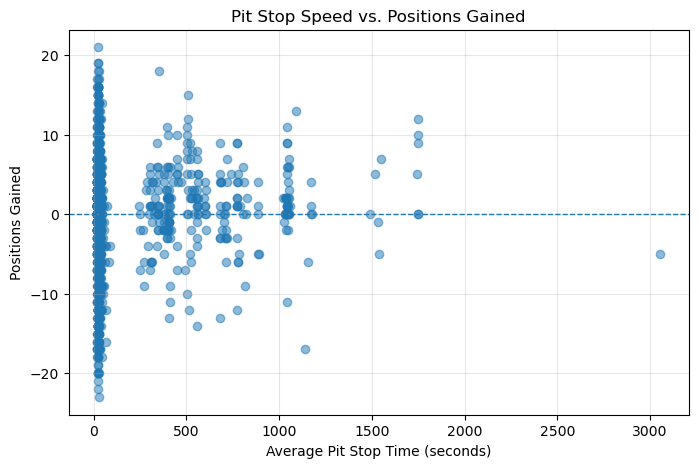

,relationship,correlation
0,Average pit stop time vs. positions gained,0.031


In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(f1_pit["avg_pit_seconds"], f1_pit["positions_gained"], alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Average Pit Stop Time (seconds)")
plt.ylabel("Positions Gained")
plt.title("Pit Stop Speed vs. Positions Gained")
plt.grid(True, alpha=0.3)
plt.show()

pit_position_correlation = f1_pit["avg_pit_seconds"].corr(f1_pit["positions_gained"])

pd.DataFrame({
    "relationship": ["Average pit stop time vs. positions gained"],
    "correlation": [pit_position_correlation]
}).round(3)

### 4. Create pit speed groups

I group average pit stop time into four quartile-based groups: Fastest, Fast, Slow, and Slowest, to compare race outcomes across different levels of pit stop speed.

In [31]:
pit_speed_order = ["Fastest", "Fast", "Slow", "Slowest"]

f1_pit["pit_speed_group"] = pd.qcut(
    f1_pit["avg_pit_seconds"].rank(method="first"),
    q=4,
    labels=pit_speed_order)

f1_pit[["avg_pit_seconds", "pit_speed_group"]].head()

,avg_pit_seconds,pit_speed_group
20776,23.319500,Fast
20777,23.213000,Fast
20778,25.109000,Slow
20779,24.055000,Slow
20780,24.058667,Slow


### 5. Pit speed group summary table

This table compares average pit time, positions gained, finishing position, points, podium rate, and sample size across the four pit speed groups.

In [32]:
def podium_rate(finish_positions):
    return (finish_positions <= 3).mean() * 100

pit_speed_summary = (
    f1_pit.groupby("pit_speed_group", observed=True)
    .agg(
        avg_pit_seconds=("avg_pit_seconds", "mean"),
        avg_positions_gained=("positions_gained", "mean"),
        avg_finish_position=("finish_position", "mean"),
        avg_points=("points", "mean"),
        podium_rate=("finish_position", podium_rate),
        count=("raceId", "count")
    )
    .reset_index()
)

pit_speed_summary = pit_speed_summary.round({
    "avg_pit_seconds": 2,
    "avg_positions_gained": 2,
    "avg_finish_position": 2,
    "avg_points": 2,
    "podium_rate": 2
})

pit_speed_summary

,pit_speed_group,avg_pit_seconds,avg_positions_gained,avg_finish_position,avg_points,podium_rate,count
0,Fastest,20.95,0.54,9.25,6.67,20.07,1126
1,Fast,22.97,0.67,10.40,5.31,16.44,1125
2,Slow,25.05,0.71,11.05,4.38,12.18,1125
3,Slowest,176.70,0.11,11.12,4.41,12.61,1126


### 6. Bar plot: average positions gained by pit speed group

This plot directly compares the average number of positions gained across the four pit speed groups.

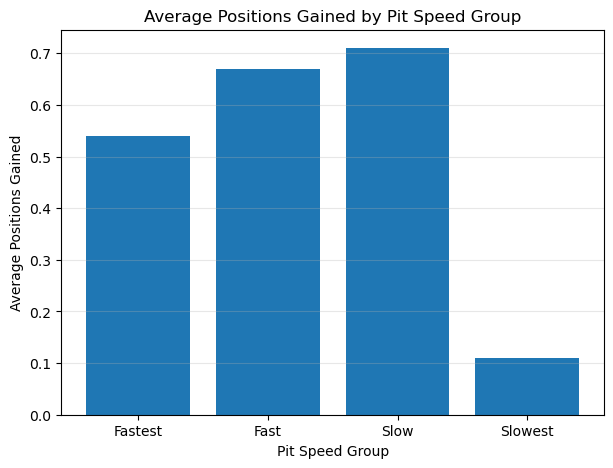

In [33]:
plt.figure(figsize=(7, 5))
plt.bar(
    pit_speed_summary["pit_speed_group"].astype(str),
    pit_speed_summary["avg_positions_gained"]
)
plt.xlabel("Pit Speed Group")
plt.ylabel("Average Positions Gained")
plt.title("Average Positions Gained by Pit Speed Group")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 7. Constructors

Formula One performance also depends on constructor resources, engineering, and race strategy. To avoid over-interpreting constructors with very few observations, I filter the constructor table to include only constructors with at least 50 races in the pit stop analysis dataset.

In [34]:
constructor_summary = (
    f1_pit.groupby("constructor_name")
    .agg(
        avg_positions_gained=("positions_gained", "mean"),
        avg_points=("points", "mean"),
        podium_rate=("finish_position", podium_rate),
        race_count=("raceId", "nunique")
    )
    .reset_index()
)

constructor_summary = constructor_summary[constructor_summary["race_count"] >= 50].copy()

constructor_summary = constructor_summary.round({
    "avg_positions_gained": 2,
    "avg_points": 2,
    "podium_rate": 2
})

top10_constructors = constructor_summary.sort_values(
    "avg_positions_gained",
    ascending=False
).head(10)

top10_constructors

,constructor_name,avg_positions_gained,avg_points,podium_rate,race_count
12,Marussia,2.57,0.02,0.00,54
4,Caterham,2.23,0.00,0.00,55
18,Sauber,1.22,1.08,1.36,158
0,Alfa Romeo,1.08,0.95,0.00,72
10,Lotus F1,0.92,5.31,18.80,74
6,Force India,0.79,3.45,1.69,157
19,Toro Rosso,0.57,1.30,0.61,178
21,Williams,0.53,2.12,3.74,228
13,McLaren,0.24,4.81,9.72,230
17,Renault,0.16,2.46,2.31,119


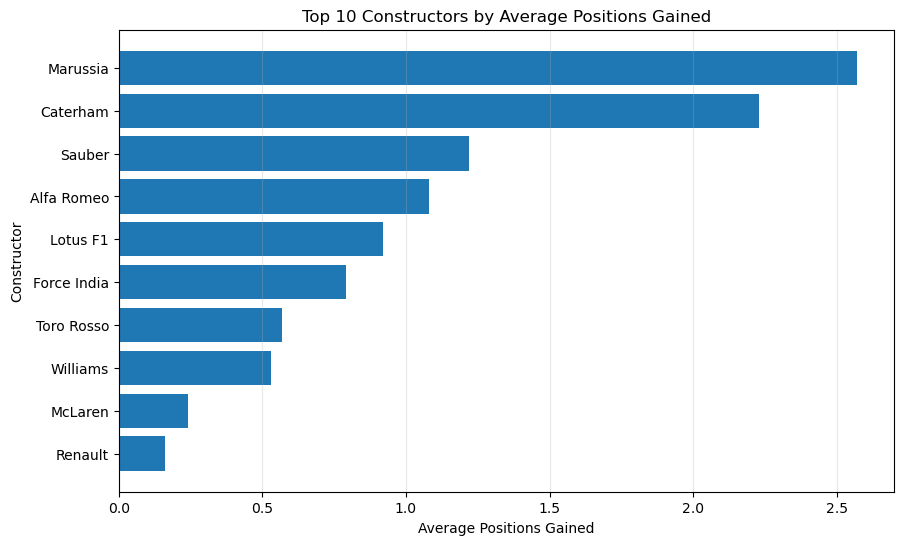

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(
    top10_constructors["constructor_name"],
    top10_constructors["avg_positions_gained"]
)
plt.xlabel("Average Positions Gained")
plt.ylabel("Constructor")
plt.title("Top 10 Constructors by Average Positions Gained")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

### 8. Year trend

This examines whether average positions gained changed over time in the subset of races with pit stop data.

In [36]:
year_trend = (
    f1_pit.groupby("year")
    .agg(
        avg_positions_gained=("positions_gained", "mean"),
        avg_pit_seconds=("avg_pit_seconds", "mean"),
        race_records=("raceId", "count")
    )
    .reset_index()
)

year_trend.round(2).head()

,year,avg_positions_gained,avg_pit_seconds,race_records
0,2011,0.46,24.77,429
1,2012,0.73,23.20,447
2,2013,0.33,24.35,401
3,2014,0.45,45.64,378
4,2015,0.47,25.82,346


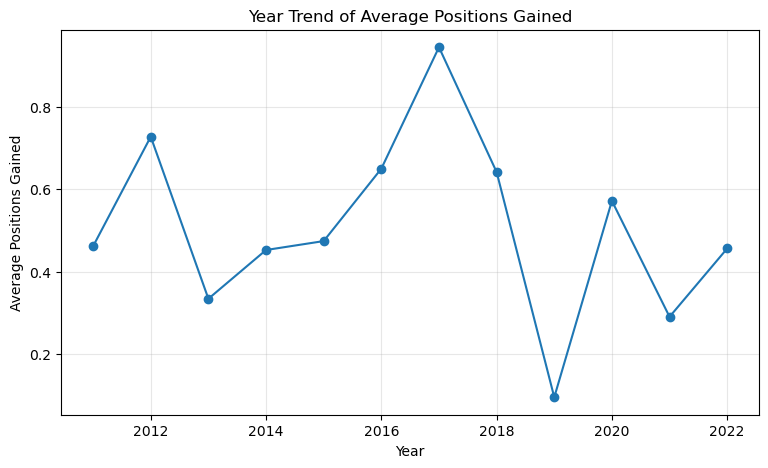

In [37]:
plt.figure(figsize=(9, 5))
plt.plot(
    year_trend["year"],
    year_trend["avg_positions_gained"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Average Positions Gained")
plt.title("Year Trend of Average Positions Gained")
plt.grid(True, alpha=0.3)
plt.show()